# analysis.diversity

This notebook is aimed to compute:
- Alpha-Diversity according to different metrics (species richness and Chao1)
- Statistical differences between habitats and disturbance levels
- Post hoc analysis

Additionally, this notebook also creates the inputs for a correlation analysis carried out later.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from daforfer import DaforferDB
import matplotlib.pyplot as plt
from miripvir25.statistics import mann_whitney_posthoc
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌──────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│         name         │                                                                                  description                                                                                   │
│       varchar        │                                                                                    varchar                                                                                     │
├──────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites              │ This table contains key information about each of the libraries, such as their site, habitat and host                                                                  

In [2]:
si = DaforferDB(conf['si'])
si.toc()

┌─────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  name   │                                                        description                                                        │
│ varchar │                                                          varchar                                                          │
├─────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1 │ Table S1: Library sites and context                                                                                       │
│ TableS2 │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3 │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4 │ Habitat-level diversity and number o

## PAB Diversity estimations


### Calculations

In [3]:
alpha_diversity = db.conn.sql('SELECT * FROM D_Site_level_div').df()
alpha_diversity

,site,habitat,disturbed,species_richness_bact,species_richness_vir,species_richness_plant,species_richness_host,coccurrence_codetections,cooccurrence_detections
0,C1,Crop,disturbed,6,18,12,4,5.0,5.0
1,C2,Crop,disturbed,8,12,17,5,1.0,1.0
2,H1,Crop,disturbed,1,13,9,3,0.0,0.0
3,H2,Crop,disturbed,1,12,9,3,1.0,1.0
4,H3,Crop,disturbed,4,33,12,4,4.0,4.0
5,M1,Crop,disturbed,2,20,14,5,3.0,1.0
6,M2,Crop,disturbed,1,13,9,4,2.0,1.0
7,M3,Crop,disturbed,2,9,11,4,0.0,0.0
8,M4,Crop,disturbed,1,9,16,3,1.0,1.0
9,Z1,Crop,disturbed,11,14,13,6,10.0,9.0


### Species richness results

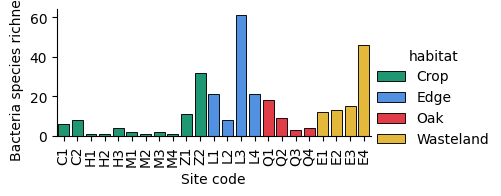

In [4]:
g = sns.catplot(alpha_diversity, x='site', y='species_richness_bact', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

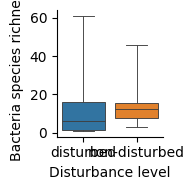

In [5]:
g = sns.catplot(
    alpha_diversity, x='disturbed', y='species_richness_bact', height=2.0, aspect=1.00, linewidth=0.65, kind='box', hue='disturbed', whis=20.0)
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Disturbance level")
g.savefig("figures/boxplot.species-richness.bydisturbance.svg")

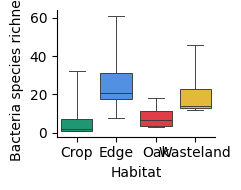

In [6]:
g = sns.catplot(
    alpha_diversity, x='habitat', y='species_richness_bact', height=2.0, aspect=1.25, 
    hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=20.0)
g.set_ylabels("Bacteria species richness")
g.set_xlabels("Habitat")
g.savefig("figures/boxplot.species-richness.byhabitat.svg")

### Diversity by disturbance level

In [7]:
q1_stats = []
for metric in ['species_richness_bact']:
    kw_h, pval = stats.mannwhitneyu(
        alpha_diversity.query('habitat == "Crop" or habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland" or habitat == "Oak"')[metric].values,
    )
    significative = pval < 0.05
    q1_stats.append(
        {'metric': metric, 'U': kw_h, 'p-val': pval, 'sign': significative}
    )
q1_stats = pd.DataFrame.from_records(q1_stats)

db.save_dataframe(
    df=q1_stats, table_name="T_ADDisturbance",
    description="Mann Whitney U test on species richness and Chao1 diversity index by disturbance level"
)
q1_stats

Saved T_ADDisturbance to db.2025-11-17


,metric,U,p-val,sign
0,species_richness_bact,39.5,0.195154,False


### Diversity by habitat

In [8]:
q2_stats = []
for metric in ['species_richness_bact']:
    kw_h, pval = stats.kruskal(
        alpha_diversity.query('habitat == "Crop"')[metric].values,
        alpha_diversity.query('habitat == "Edge"')[metric].values,
        alpha_diversity.query('habitat == "Wasteland"')[metric].values,
        alpha_diversity.query('habitat == "Oak"')[metric].values
    )
    significative = pval < 0.05
    q2_stats.append(
        {'metric': metric, 'H': kw_h, 'p-val': pval, 'sign': significative}
    )
q2_stats = pd.DataFrame.from_records(q2_stats)

db.save_dataframe(
    df=q2_stats, table_name="T_ADhabitat",
    description="Kruskal Wallis test on species richness and Chao1 diversity index by habitat"
)
q2_stats

Saved T_ADhabitat to db.2025-11-17


,metric,H,p-val,sign
0,species_richness_bact,10.430597,0.015239,True


### Diversity by habitat, post-hoc analysis

In [9]:
q3_stats_df = mann_whitney_posthoc(alpha_diversity, 'habitat', 'species_richness_bact')# .reset_index()
db.save_dataframe(
    df=q3_stats_df, table_name="T_ADHabitatPH",
    description="Post-Hoc Mann Whitney U analysis on species richness and Chao1 diversity index by habitat. Using group1 < group2 test"
)
si.save_dataframe(
    df=q3_stats_df, table_name="TableS5",
    description="Mann-Whitney U post-hoc test on site-diversity by habitat"
)
# q3_stats_df
q3_stats_df

Saved T_ADHabitatPH to db.2025-11-17
Saved TableS5 to si.2025-11-17


,group_1,group_2,U,p-val,sign
0,Crop,Edge,39.5,0.024723,True
1,Crop,Oak,31.5,0.234904,False
2,Crop,Wasteland,41.0,0.014711,True
3,Edge,Crop,39.5,0.024723,True
4,Edge,Oak,14.0,0.110210,False
5,Edge,Wasteland,10.0,0.663117,False
6,Oak,Crop,31.5,0.234904,False
7,Oak,Edge,14.0,0.110210,False
8,Oak,Wasteland,13.0,0.200000,False
9,Wasteland,Crop,41.0,0.014711,True


In [10]:
q3_stats_df.pivot(index='group_1', columns='group_2', values='p-val')

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,0.024723,0.234904,0.014711
Edge,0.024723,NaN,0.110210,0.663117
Oak,0.234904,0.110210,NaN,0.200000
Wasteland,0.014711,0.663117,0.200000,NaN


In [11]:
q3_stats_df.pivot(index='group_1', columns='group_2', values='U').round(4)

group_2,Crop,Edge,Oak,Wasteland
group_1,,,,
Crop,NaN,39.5,31.5,41.0
Edge,39.5,NaN,14.0,10.0
Oak,31.5,14.0,NaN,13.0
Wasteland,41.0,10.0,13.0,NaN


In [12]:
db.conn.close()
si.conn.close()